In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
# =========================
# 0) CONFIG (F8)
# =========================

# Paths (as provided)
INPUTS_PATH = "data/F8/initial_inputs.npy"
OUTPUTS_PATH = "data/F8/initial_outputs.npy"

# Problem setup
MAXIMIZE = True
D = 8
BOUNDS = np.array([[0.0, 1.0]] * D)  # inferred from data ranges; safe for your dataset

# Acquisition settings (UCB for maximisation)
KAPPA = 2.0

# Candidate generation
N_CAND_GLOBAL = 8000
N_CAND_BIASED = 8000
N_CAND_LOCAL  = 4000
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [3]:
# =========================
# 1) LOAD DATA
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH).reshape(-1)

assert X.ndim == 2 and X.shape[1] == D, f"Expected X shape (n,{D}), got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,), got {y.shape}"

print("F8 SHAPE - Inputs:", X.shape, "Outputs:", y.shape)
print("Last row - X:", X[-1])
print("Last value - y:", y[-1])
print("\nX min per dim:", np.min(X, axis=0))
print("X max per dim:", np.max(X, axis=0))
print("y min/max:", float(np.min(y)), float(np.max(y)))

F8 SHAPE - Inputs: (42, 8) Outputs: (42,)
Last row - X: [0.231868 0.356115 0.159692 0.196372 0.938094 0.792984 0.113027 0.830933]
Last value - y: 9.8021068497701

X min per dim: [0.00907698 0.0034195  0.02292868 0.00904349 0.00964888 0.02211341
 0.03590888 0.04195607]
X max per dim: [0.98594539 0.97397979 0.9988855  0.90298577 0.986902   0.99024381
 0.99291449 0.9887551 ]
y min/max: 5.5921933895401965 9.8021068497701


In [6]:
# =========================
# 2) SURROGATE MODELS
#    - GP (mean + std)
#    - RF (mean + tree-std as uncertainty proxy)
#    - GBM ensemble (mean + ensemble-std)
# =========================

# Scale X for GP (and also helps other models be consistent)
x_scaler = StandardScaler()
Xz = x_scaler.fit_transform(X)

# Standardise y for GP stability (we convert back when needed)
y_mean, y_std = float(np.mean(y)), float(np.std(y) + 1e-12)
yz = (y - y_mean) / y_std

# --- Gaussian Process ---
kernel = (
    ConstantKernel(1.0) *
    Matern(length_scale=np.ones(D), nu=2.5) +
    WhiteKernel(noise_level=1e-4)
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    optimizer=None,          # <-- disables hyperparameter optimization
    normalize_y=False,
    random_state=RANDOM_SEED,
    alpha=1e-10
)
gp.fit(Xz, yz)

# --- GBM Ensemble ---
gbm_ensemble = []
gbm_seeds = [0, 1, 2, 3, 4, 5]
for s in gbm_seeds:
    m = GradientBoostingRegressor(
        random_state=s,
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.85
    )
    m.fit(X, y)
    gbm_ensemble.append(m)

print("Surrogates trained: GP + RF + GBM ensemble (k=%d)" % len(gbm_ensemble))


Surrogates trained: GP + RF + GBM ensemble (k=6)


In [7]:
# =========================
# 3) UNCERTAINTY ESTIMATION HELPERS
# =========================
def gp_predict_mu_sigma(Xcand):
    Xc_z = x_scaler.transform(Xcand)
    mu_z, std_z = gp.predict(Xc_z, return_std=True)
    mu = mu_z * y_std + y_mean
    sigma = std_z * y_std
    return mu, sigma

def rf_predict_mu_sigma(Xcand):
    # mean across trees + std across tree predictions (uncertainty proxy)
    tree_preds = np.array([t.predict(Xcand) for t in rf.estimators_])  # (n_trees, n)
    mu = tree_preds.mean(axis=0)
    sigma = tree_preds.std(axis=0)
    return mu, sigma

def gbm_predict_mu_sigma(Xcand):
    preds = np.array([m.predict(Xcand) for m in gbm_ensemble])  # (k, n)
    mu = preds.mean(axis=0)
    sigma = preds.std(axis=0)  # ensemble spread
    return mu, sigma

def fuse_ensemble(mu_list, sig_list):
    """
    Combine model predictions into a single (mu, sigma).
    sigma combines: mean(model variances) + variance(model means)
    """
    MU = np.vstack(mu_list)      # (m, n)
    SG = np.vstack(sig_list)     # (m, n)
    mu = MU.mean(axis=0)
    # law of total variance style combination
    sigma2 = (SG**2).mean(axis=0) + MU.var(axis=0)
    sigma = np.sqrt(np.maximum(sigma2, 1e-12))
    return mu, sigma


In [8]:
# =========================
# 4) ACQUISITION + CANDIDATE GENERATION
#    Goal (MAXIMISE):
#      - Emphasise high x4
#      - Keep x1 low/moderate
#      - Vary x2 and x3 jointly
#      - Prioritise exploration near high x3 and x4
# =========================
rng = np.random.default_rng(RANDOM_SEED)

def clip01(A):
    return np.clip(A, 0.0, 1.0)

# ---- (A) Global random candidates
Xcand_global = rng.uniform(0, 1, size=(N_CAND_GLOBAL, D))

# ---- (B) Biased candidates: x1 low, x4 high, encourage x3 high-ish
# Use Beta distributions to skew:
# x1 ~ Beta(1,5) -> low
# x4 ~ Beta(5,1) -> high
# x3 ~ Beta(3,1.4) -> somewhat high
Xcand_biased = rng.uniform(0, 1, size=(N_CAND_BIASED, D))
Xcand_biased[:, 0] = rng.beta(1.0, 5.0, size=N_CAND_BIASED)      # x1 low
Xcand_biased[:, 3] = rng.beta(5.0, 1.0, size=N_CAND_BIASED)      # x4 high (0-indexed: x4 is dim 4 -> index 3)
Xcand_biased[:, 2] = rng.beta(3.0, 1.4, size=N_CAND_BIASED)      # x3 higher (x3 index 2)

# ---- (C) Local candidates around current best region (top points)
best_idx = int(np.argmax(y)) if MAXIMIZE else int(np.argmin(y))
x_best = X[best_idx]

# Also use centroid of top-k to guide x2/x3 joint variation
k_top = min(6, len(y))
top_idx = np.argsort(y)[-k_top:] if MAXIMIZE else np.argsort(y)[:k_top]
x_top_mean = X[top_idx].mean(axis=0)

# Sample around x_top_mean with correlated-ish noise on (x2,x3) and push x4 up a bit
Xcand_local = np.tile(x_top_mean, (N_CAND_LOCAL, 1))
noise = rng.normal(0, 0.08, size=(N_CAND_LOCAL, D))
# stronger joint variation on x2 & x3 (indices 1 and 2)
noise[:, 1] *= 1.4
noise[:, 2] *= 1.4
# gently nudge x4 upward (index 3)
noise[:, 3] += np.abs(rng.normal(0, 0.05, size=N_CAND_LOCAL))
# keep x1 from drifting high (index 0) by biasing downward
noise[:, 0] -= np.abs(rng.normal(0, 0.05, size=N_CAND_LOCAL))

Xcand_local = clip01(Xcand_local + noise)

# Combine all candidates
Xcand = np.vstack([Xcand_global, Xcand_biased, Xcand_local])

# ---- Predict with each surrogate, then fuse
mu_gp, sg_gp   = gp_predict_mu_sigma(Xcand)
mu_rf, sg_rf   = rf_predict_mu_sigma(Xcand)
mu_gbm, sg_gbm = gbm_predict_mu_sigma(Xcand)

mu, sigma = fuse_ensemble([mu_gp, mu_rf, mu_gbm], [sg_gp, sg_rf, sg_gbm])

# ---- UCB acquisition for maximisation
# If this were minimisation, you'd use mu - kappa*sigma
score = mu + KAPPA * sigma if MAXIMIZE else -(mu - KAPPA * sigma)

best_cand_idx = int(np.argmax(score))
x_next = Xcand[best_cand_idx]

print("Selected candidate index:", best_cand_idx)
print("Predicted mu:", float(mu[best_cand_idx]))
print("Predicted sigma:", float(sigma[best_cand_idx]))
print("Acquisition score:", float(score[best_cand_idx]))


Selected candidate index: 6599
Predicted mu: 9.03177406057243
Predicted sigma: 0.9491060734931994
Acquisition score: 10.929986207558828


OOF RF diagnostic: R2=0.678  MAE=0.435


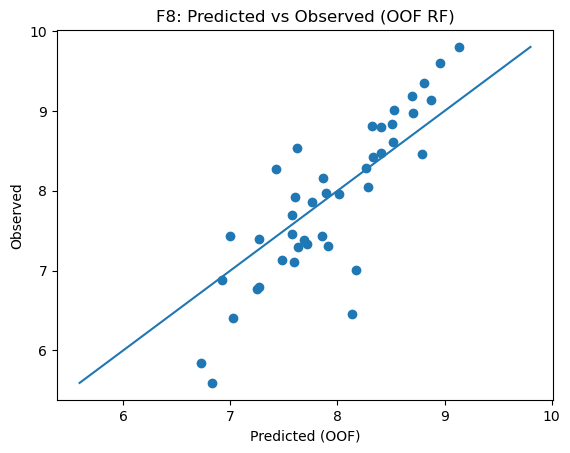

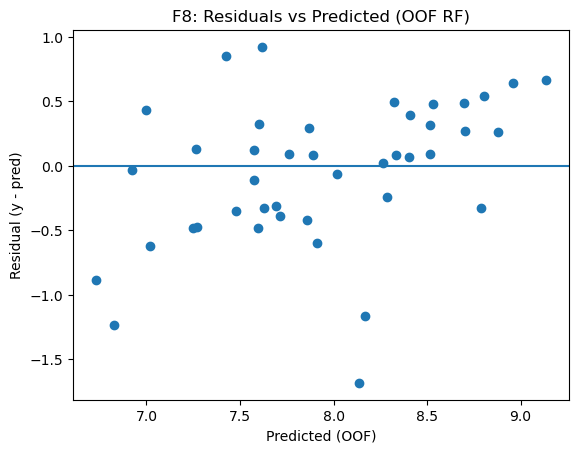

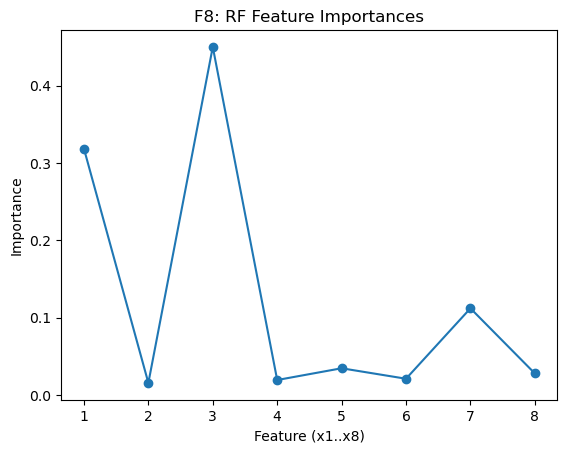

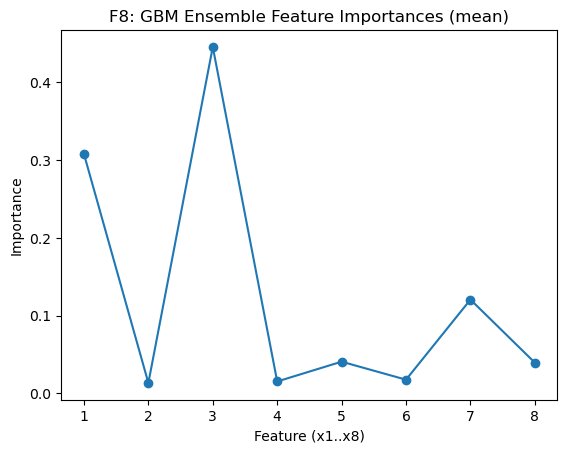

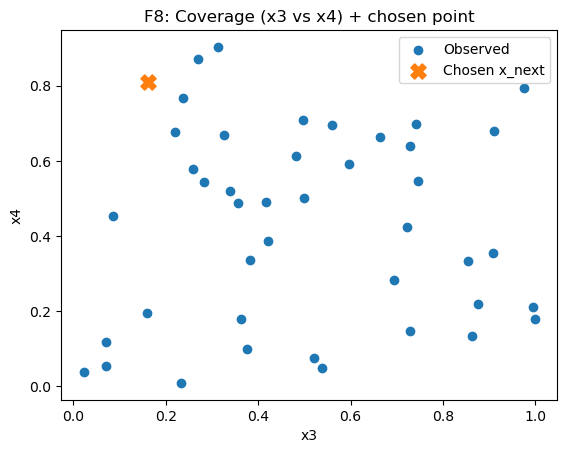

In [9]:
# =========================
# 5) DIAGNOSTICS
#    - Pred mean vs observed (CV-ish quick check)
#    - Residuals
#    - Feature importances (RF + GBM)
#    - Coverage check (x3 vs x4)
# =========================

# (A) Quick KFold diagnostic using RF (fast + stable)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
oof = np.zeros_like(y, dtype=float)

for tr, te in kf.split(X):
    m = RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=RANDOM_SEED, n_jobs=-1
    )
    m.fit(X[tr], y[tr])
    oof[te] = m.predict(X[te])

r2 = r2_score(y, oof)
mae = mean_absolute_error(y, oof)
resid = y - oof

print(f"OOF RF diagnostic: R2={r2:.3f}  MAE={mae:.3f}")

plt.figure()
plt.scatter(oof, y)
mn = min(oof.min(), y.min()); mx = max(oof.max(), y.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Predicted (OOF)")
plt.ylabel("Observed")
plt.title("F8: Predicted vs Observed (OOF RF)")
plt.show()

plt.figure()
plt.scatter(oof, resid)
plt.axhline(0)
plt.xlabel("Predicted (OOF)")
plt.ylabel("Residual (y - pred)")
plt.title("F8: Residuals vs Predicted (OOF RF)")
plt.show()

# (B) Feature importances
rf_imp = rf.feature_importances_
gbm_imp = np.mean([m.feature_importances_ for m in gbm_ensemble], axis=0)

plt.figure()
plt.plot(np.arange(1, D+1), rf_imp, marker='o')
plt.xticks(np.arange(1, D+1))
plt.xlabel("Feature (x1..x8)")
plt.ylabel("Importance")
plt.title("F8: RF Feature Importances")
plt.show()

plt.figure()
plt.plot(np.arange(1, D+1), gbm_imp, marker='o')
plt.xticks(np.arange(1, D+1))
plt.xlabel("Feature (x1..x8)")
plt.ylabel("Importance")
plt.title("F8: GBM Ensemble Feature Importances (mean)")
plt.show()

# (C) Coverage check: x3 vs x4 of observed + chosen point
plt.figure()
plt.scatter(X[:, 2], X[:, 3], label="Observed")
plt.scatter([x_next[2]], [x_next[3]], marker='X', s=120, label="Chosen x_next")
plt.xlabel("x3")
plt.ylabel("x4")
plt.title("F8: Coverage (x3 vs x4) + chosen point")
plt.legend()
plt.show()


In [10]:
# =========================
# 6) OUTPUT: ONE ROW TO SUBMIT
# =========================
x_submit = x_next.copy()

print("=== RECOMMENDED NEXT X (submit this 1 row) ===")
print(x_submit)
print("Shape:", x_submit.shape)

print("\nRounded (6 dp):")
print(np.round(x_submit, 6))


=== RECOMMENDED NEXT X (submit this 1 row) ===
[0.21856053 0.09871216 0.16125862 0.80875132 0.95606325 0.93682785
 0.01283639 0.9950715 ]
Shape: (8,)

Rounded (6 dp):
[0.218561 0.098712 0.161259 0.808751 0.956063 0.936828 0.012836 0.995072]
